In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ruptures as rpt
from kernelcpd import binseg
import matplotlib.ticker as mticker

In [ ]:
# Load data
df = pd.read_csv("real_datasets/gdp_japan/gdp_japan.csv")

In [ ]:
year_cols = [col for col in df.columns if col.isdigit()]

In [ ]:
df_plot = df[year_cols].T.reset_index()
df_plot.columns = ["Year", "GDP"]

In [ ]:
# Build signal
signal = df_plot["GDP"].to_numpy()

# Normalize
y = (signal - np.mean(signal)) / np.std(signal)

In [8]:
binseg(
    sequence=y.reshape(-1, 1),
    n_changepoints=1,
    model="srbf",
    T=3,
    laplace_option="dirichlet",
    kernel_type='gaussian',
)

array([30])

In [12]:
def detect_all_models(y, n_bkps):
    """Run all models once for a single signal."""
    out = {}
    out["linear"] = rpt.KernelCPD(kernel="linear").fit(y).predict(n_bkps=n_bkps)[0]
    out["cosine"] = rpt.KernelCPD(kernel="cosine").fit(y).predict(n_bkps=n_bkps)[0]
    out["rbf"] = rpt.KernelCPD(kernel="rbf").fit(y).predict(n_bkps=n_bkps)[0]
    out["proposed"] = (
            binseg(
                sequence=y.reshape(-1, 1),
                n_changepoints=1,
                model="srbf",
                T=5,
                laplace_option="dirichlet",
                kernel_type='gaussian',
            )[0] + 1
        )
    return out

In [13]:
chpnts_dict = detect_all_models(y, 1)

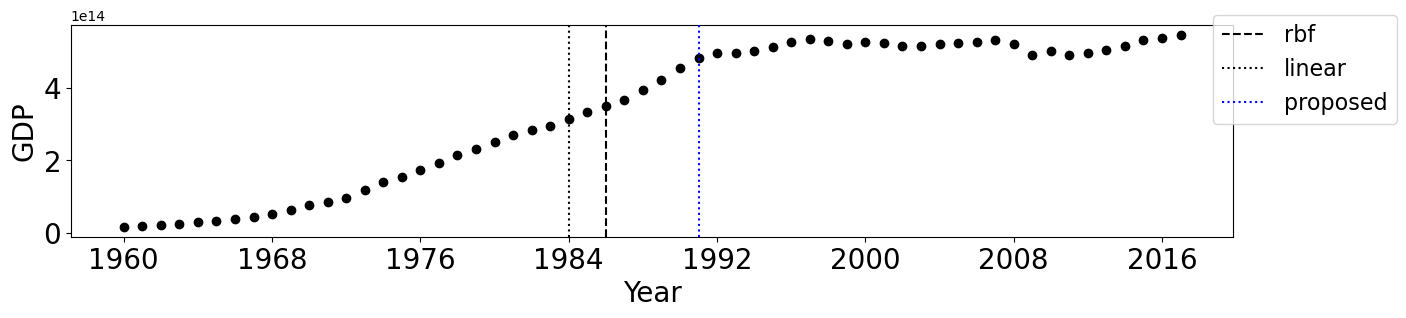

In [23]:
chosen_methods = ["label", "rbf", "linear", "proposed"]
chpnts_dict_final = {k: chpnts_dict[k] for k in chosen_methods if k in chpnts_dict}

linestyles = {
    "label": "-",
    "linear": ":",
    "rbf": "--",
    "cosine": "-.",
    "proposed": ":",
}

plt.figure(figsize=(15, 2.75))
plt.scatter(
    df_plot["Year"],
    signal,
    color='black'
)
plt.xlabel("Year", fontsize=20)
plt.ylabel("GDP", fontsize=20)

ax = plt.gca()

for method, cp in chpnts_dict_final.items():
    plt.axvline(
        df_plot["Year"].iloc[cp],
        linestyle = linestyles.get(method, "--"),
        color = "red" if method == "label" else "blue" if method == "proposed"  else "black",
        zorder = 0    if method == "label" else 10,
        label = method
    )
ax.xaxis.set_major_locator(mticker.MaxNLocator(nbins=8))

# remove duplicate legend entries
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), loc="upper right", bbox_to_anchor=(1.15, 1.1), fontsize=16)
plt.tick_params(axis='both', labelsize=20)
plt.show()